In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DB_PATH = "../outputs/olist.db"
conn    = sqlite3.connect(DB_PATH)

print("Libraries loaded. Database connected.")

Libraries loaded. Database connected.


In [2]:
df_rfm = pd.read_sql("""
    SELECT
        c.customer_unique_id                              AS customer_id,
        COUNT(DISTINCT o.order_id)                        AS frequency,
        ROUND(SUM(p.payment_value), 2)                    AS monetary,
        JULIANDAY('2018-10-01') - 
        JULIANDAY(MAX(o.order_purchase_timestamp))        AS recency_days
    FROM customers   c
    JOIN orders      o ON c.customer_id      = o.customer_id
    JOIN payments    p ON o.order_id         = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
""", conn)

conn.close()

print(f"Total unique customers: {len(df_rfm):,}")
print(f"\nRFM Table Preview:")
print(df_rfm.head(10).to_string(index=False))
print(f"\nAverage spend per customer:  ${df_rfm['monetary'].mean():.2f}")
print(f"Average orders per customer: {df_rfm['frequency'].mean():.2f}")
print(f"Average recency (days ago):  {df_rfm['recency_days'].mean():.0f} days")

Total unique customers: 93,344

RFM Table Preview:
                     customer_id  frequency  monetary  recency_days
0000366f3b9a7992bf8c76cfdf3221e2          1    141.90    143.544132
0000b849f77a49e4a4ce2b2a4ca5be3f          1     27.19    146.533715
0000f46a3911fa3c0805444483337064          1     86.22    569.121493
0000f6ccb0745a6a4b88665a16c9f078          1     43.62    353.146053
0004aac84e0df4da2b147fca70cf8255          1    196.89    320.176597
0004bd2a26a76fe21f786e4fbd80607f          1    166.98    178.185231
00050ab1314c0e55a6ca13cf7181fecf          1     35.38    163.460150
00053a61a98854899e70ed204dd4bafe          1    419.18    214.530775
0005e1862207bf6ccc02e4228effd9a0          1    150.12    575.019306
0005ef4cd20d2893f0d9fbd94d3c0d97          1    129.76    202.359583

Average spend per customer:  $165.20
Average orders per customer: 1.03
Average recency (days ago):  270 days


In [3]:
# Score each customer 1-4 on Recency, Frequency, Monetary
df_rfm['R'] = pd.qcut(df_rfm['recency_days'],  q=4, labels=[4,3,2,1])
df_rfm['F'] = pd.qcut(df_rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
df_rfm['M'] = pd.qcut(df_rfm['monetary'],       q=4, labels=[1,2,3,4])

df_rfm['R'] = df_rfm['R'].astype(int)
df_rfm['F'] = df_rfm['F'].astype(int)
df_rfm['M'] = df_rfm['M'].astype(int)

df_rfm['rfm_score'] = df_rfm['R'] + df_rfm['F'] + df_rfm['M']

# Assign segment labels based on score
def assign_segment(row):
    score = row['rfm_score']
    r     = row['R']
    if r == 4 and score >= 10:
        return 'Champions'
    elif r >= 3 and score >= 9:
        return 'Loyal Customers'
    elif r >= 3 and score >= 7:
        return 'Potential Loyalists'
    elif r >= 2 and score >= 6:
        return 'At Risk'
    else:
        return 'Lost'

df_rfm['segment'] = df_rfm.apply(assign_segment, axis=1)

print("=== Customer Segments ===")
segment_summary = df_rfm.groupby('segment').agg(
    customers  = ('customer_id',  'count'),
    avg_spend  = ('monetary',     'mean'),
    avg_orders = ('frequency',    'mean'),
    avg_recency= ('recency_days', 'mean')
).round(2).sort_values('customers', ascending=False)

print(segment_summary.to_string())
print(f"\nTotal customers segmented: {len(df_rfm):,}")

=== Customer Segments ===
                     customers  avg_spend  avg_orders  avg_recency
segment                                                           
Lost                     29249     142.03        1.02       442.16
At Risk                  23294     162.87        1.03       281.52
Potential Loyalists      17420     108.86        1.00       151.87
Loyal Customers          14494     219.48        1.06       155.19
Champions                 8887     269.50        1.10        89.79

Total customers segmented: 93,344


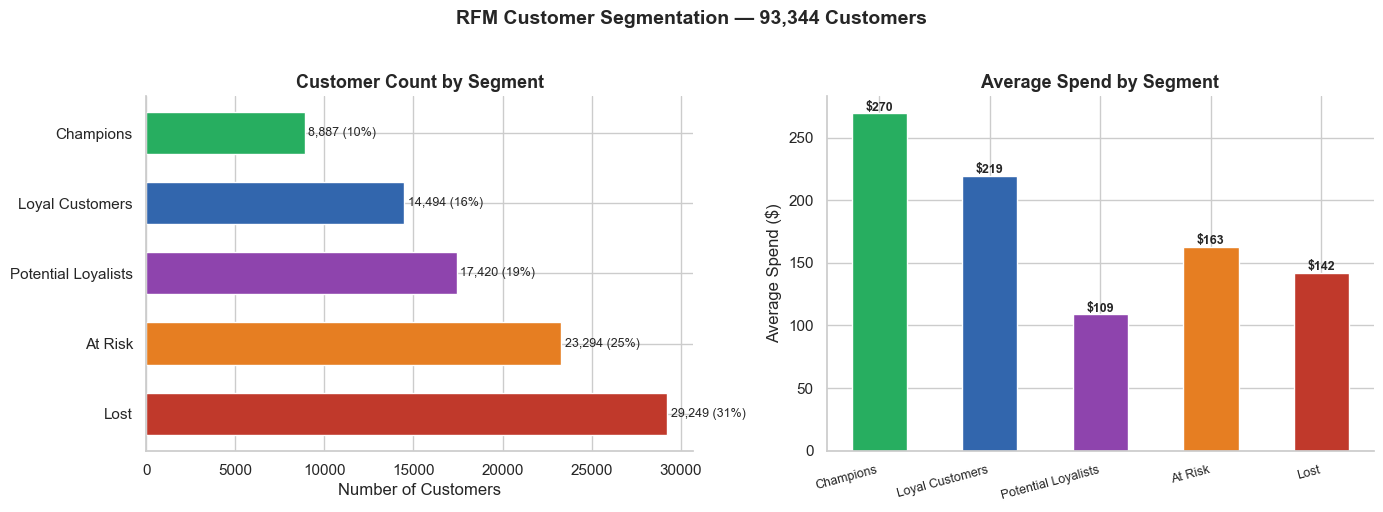

Chart saved.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

segment_order  = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
segment_colors = ['#27AE60','#3266ad','#8E44AD','#E67E22','#C0392B']

counts = [df_rfm[df_rfm['segment']==s].shape[0] for s in segment_order]
ax1.barh(segment_order[::-1], counts[::-1],
         color=segment_colors[::-1], height=0.6)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customer Count by Segment',
              fontsize=13, fontweight='bold')
for i, (count, seg) in enumerate(zip(counts[::-1], segment_order[::-1])):
    pct = count / len(df_rfm) * 100
    ax1.text(count + 200, i, f'{count:,} ({pct:.0f}%)',
             va='center', fontsize=9)

avg_spends = [df_rfm[df_rfm['segment']==s]['monetary'].mean() for s in segment_order]
bars = ax2.bar(segment_order, avg_spends,
               color=segment_colors, width=0.5)
ax2.set_ylabel('Average Spend ($)')
ax2.set_title('Average Spend by Segment',
              fontsize=13, fontweight='bold')
ax2.set_xticklabels(segment_order, rotation=15, ha='right', fontsize=9)
for bar, val in zip(bars, avg_spends):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'${val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('RFM Customer Segmentation — 93,344 Customers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart5_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [5]:
# Save segmented customers to database
conn = sqlite3.connect(DB_PATH)
df_rfm.to_sql("customer_segments", conn, if_exists="replace", index=False)
conn.close()

# Build retention strategy per segment
strategies = {
    'Champions': {
        'size': 8887,
        'avg_spend': '$270',
        'action': 'Reward them — early access, loyalty perks, referral programme',
        'goal': 'Turn them into brand ambassadors'
    },
    'Loyal Customers': {
        'size': 14494,
        'avg_spend': '$219',
        'action': 'Upsell higher value categories — electronics, computers',
        'goal': 'Increase average order value'
    },
    'Potential Loyalists': {
        'size': 17420,
        'avg_spend': '$109',
        'action': 'Send personalised follow-up offers within 30 days of purchase',
        'goal': 'Trigger second purchase before they go cold'
    },
    'At Risk': {
        'size': 23294,
        'avg_spend': '$163',
        'action': 'Win-back campaign — discount + free shipping offer',
        'goal': 'Re-engage before they become Lost'
    },
    'Lost': {
        'size': 29249,
        'avg_spend': '$142',
        'action': 'Low-cost email reactivation — do not over-invest',
        'goal': 'Recover 5-10% at minimal cost'
    }
}

print("=== RETENTION STRATEGY BY SEGMENT ===\n")
for segment, info in strategies.items():
    print(f"Segment:    {segment} ({info['size']:,} customers | avg spend {info['avg_spend']})")
    print(f"Action:     {info['action']}")
    print(f"Goal:       {info['goal']}")
    print()

# Revenue opportunity calculation
at_risk_customers  = 23294
avg_spend_loyal    = 219
recovery_rate      = 0.10
revenue_opportunity = at_risk_customers * recovery_rate * avg_spend_loyal

print("=== REVENUE OPPORTUNITY ===")
print(f"If 10% of At Risk customers are converted to Loyal:")
print(f"  {at_risk_customers:,} x 10% x ${avg_spend_loyal} = ${revenue_opportunity:,.0f} additional revenue")

=== RETENTION STRATEGY BY SEGMENT ===

Segment:    Champions (8,887 customers | avg spend $270)
Action:     Reward them — early access, loyalty perks, referral programme
Goal:       Turn them into brand ambassadors

Segment:    Loyal Customers (14,494 customers | avg spend $219)
Action:     Upsell higher value categories — electronics, computers
Goal:       Increase average order value

Segment:    Potential Loyalists (17,420 customers | avg spend $109)
Action:     Send personalised follow-up offers within 30 days of purchase
Goal:       Trigger second purchase before they go cold

Segment:    At Risk (23,294 customers | avg spend $163)
Action:     Win-back campaign — discount + free shipping offer
Goal:       Re-engage before they become Lost

Segment:    Lost (29,249 customers | avg spend $142)
Action:     Low-cost email reactivation — do not over-invest
Goal:       Recover 5-10% at minimal cost

=== REVENUE OPPORTUNITY ===
If 10% of At Risk customers are converted to Loyal:
  23,294